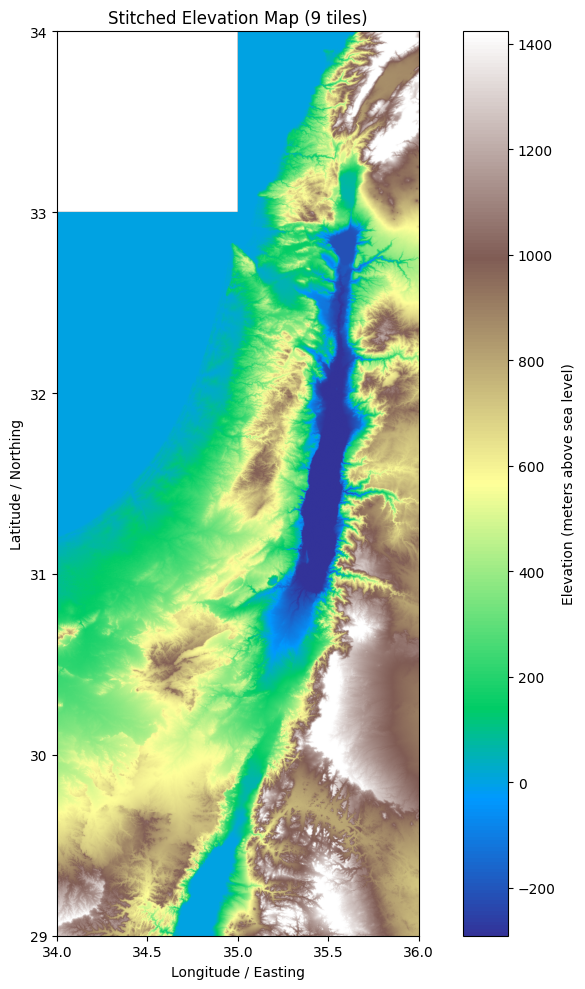

In [1]:
import rasterio
from rasterio.merge import merge
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Directory containing the .hgt files
data_dir = Path("../../data/elevation_data")
hgt_files = list(data_dir.glob("*.hgt"))

src_files_to_mosaic = []
try:
    for fp in hgt_files:
        src = rasterio.open(fp)
        src_files_to_mosaic.append(src)
    
    # Merge and get first band
    mosaic, out_trans = merge(src_files_to_mosaic)
    elevation = mosaic[0]
    height, width = elevation.shape
    
    # geographic bounds
    left, top = out_trans * (0, 0)
    right, bottom = out_trans * (width, height)
    extent = [left, right, bottom, top]

    # Downsample
    step = 10
    # We must convert to floats before we can use np.nan!
    display_elevation = elevation[::step, ::step].astype(float)
    
    # ------ THE COLOR FIX ------
    # Detect the bad "no-data" constant (-32768) and overwrite it with NaN
    nodata = src_files_to_mosaic[0].nodata if src_files_to_mosaic[0].nodata is not None else -32768
    display_elevation[display_elevation <= nodata] = np.nan
    
    # Calculate vmin/vmax ignoring the NaNs
    valid_data = display_elevation[~np.isnan(display_elevation)]
    vmin, vmax = np.percentile(valid_data, [2, 98])
    # ---------------------------

    # Set up plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Matplotlib will organically treat 'np.nan' as transparent/white space
    img = ax.imshow(display_elevation, cmap='terrain', extent=extent, vmin=vmin, vmax=vmax)
    
    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Elevation (meters above sea level)')
    
    ax.set_title(f"Stitched Elevation Map ({len(hgt_files)} tiles)")
    ax.set_xlabel('Longitude / Easting')
    ax.set_ylabel('Latitude / Northing')
    
    plt.tight_layout()
    plt.show()

finally:
    for src in src_files_to_mosaic:
        src.close()


In [2]:
from weather_engine.database import engine
import pandas as pd

query = "SELECT * FROM station_metadata JOIN station_neighbors USING (station_id)"
target_ids = (16, 500, 22, 178)

df = pd.read_sql(query, engine)
df

,station_id,latitude,longitude,elevation,is_boundary,neighbor_1_id,neighbor_1_distance,neighbor_2_id,neighbor_2_distance,neighbor_3_id,neighbor_3_distance
0,2,32.8174,35.7622,378,1,227,9.844006,6,12.550969,233,18.607819
1,6,32.8800,35.6504,-201,0,233,6.660087,227,9.596414,2,12.550969
2,8,32.7024,35.5839,-201,0,11,6.924503,2,21.011769,380,24.825156
3,10,33.1288,35.8045,942,1,202,18.425346,499,19.184965,241,25.136533
4,11,32.6978,35.5101,-3,0,8,6.924503,502,8.942013,380,20.034293
...,...,...,...,...,...,...,...,...,...,...,...
61,381,30.9830,34.7080,305,0,98,15.039543,112,16.785660,58,44.152967
62,411,31.2642,34.8045,303,0,349,13.024144,112,21.961249,79,30.484901
63,499,33.2254,35.6337,128,1,241,6.190793,202,6.276197,10,19.184965
64,500,32.7104,35.3034,443,0,13,9.700412,186,11.698846,205,19.382367


In [3]:
import weather_engine.spatial as sp

meta_dict = {row.station_id: (row.latitude, row.longitude) for row in df.itertuples()}
print(meta_dict)

test_neighbors = [sp.get_k_neighbors(target, meta_dict, 16) for target in target_ids]
print(test_neighbors)

{2: (32.8174, 35.7622), 6: (32.88, 35.6504), 8: (32.7024, 35.5839), 10: (33.1288, 35.8045), 11: (32.6978, 35.5101), 13: (32.7053, 35.4069), 16: (32.596, 35.2769), 20: (32.1752, 35.0959), 21: (32.1056, 35.2114), 22: (31.7704, 35.1973), 23: (31.7806, 35.2217), 24: (31.9449, 35.1499), 25: (31.6898, 34.9744), 28: (31.3568, 35.0662), 29: (31.25, 35.1855), 30: (31.9973, 35.4509), 33: (30.7787, 35.2389), 36: (29.8851, 35.0771), 42: (32.7611, 35.0208), 43: (32.774, 35.0225), 44: (32.6808, 34.9594), 45: (32.5724, 34.9546), 46: (32.4732, 34.8815), 54: (32.0073, 34.8138), 58: (31.2716, 34.3894), 65: (31.0306, 35.3919), 67: (32.6028, 35.0964), 73: (33.0653, 35.2173), 77: (31.6644, 35.1233), 78: (32.8466, 35.1123), 79: (31.5036, 34.648), 82: (31.6585, 34.6798), 90: (32.1598, 35.3513), 98: (30.8702, 34.795), 106: (33.0806, 35.1079), 112: (31.0708, 34.8513), 121: (31.791, 34.805), 178: (32.058, 34.7588), 186: (32.7078, 35.1784), 188: (31.7878, 35.1258), 202: (33.1716, 35.6133), 205: (32.8847, 35.3012

In [4]:
import folium

m = folium.Map(location=[31.5, 34.8], zoom_start=8, tiles='cartodbpositron')

target_names = {16: 'Afula', 500: 'Nazareth', 22: 'Jerusalem', 178: 'Tel Aviv'}
colors = ['red', 'blue', 'green', 'purple']

for result, color in zip(test_neighbors, colors):
    tid = result['station_id']
    tlat, tlon = meta_dict[tid]
    neighbor_ids = [result[f'neighbor_{i}_id'] for i in range(1, 4)]
    neighbor_coords = [meta_dict[nid] for nid in neighbor_ids]

    # Triangle for interpolation stations, dashed line for boundary fallback
    triangle_points = [(lat, lon) for lat, lon in neighbor_coords] + [neighbor_coords[0]]
    dash = '8' if result['is_boundary'] else None
    folium.PolyLine(triangle_points, color=color, weight=2, dash_array=dash).add_to(m)

    # Neighbor stations
    for nid, (nlat, nlon) in zip(neighbor_ids, neighbor_coords):
        folium.CircleMarker(
            location=[nlat, nlon],
            radius=6,
            color=color,
            fill=True,
            fill_opacity=0.8,
            popup=f"Neighbor {nid} of {target_names[tid]}"
        ).add_to(m)

    # Target station
    boundary_label = " (boundary)" if result['is_boundary'] else ""
    folium.Marker(
        location=[tlat, tlon],
        popup=f"{target_names[tid]} (id={tid}){boundary_label}",
        icon=folium.Icon(color='red', icon='star')
    ).add_to(m)

m
